In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [3]:
TRAIN_CSV_PATH = os.path.join("..", "data", "raw", "emnist-letters-train.csv")
TEST_CSV_PATH = os.path.join("..", "data", "raw", "emnist-letters-test.csv")

train_df = pd.read_csv(TRAIN_CSV_PATH, header=None)
test_df = pd.read_csv(TEST_CSV_PATH, header=None)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()


Train shape: (88800, 785)
Test shape: (14800, 785)


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,16,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,23,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Filter Dataset to Grades A–F

The EMNIST Letters dataset contains labels from **1 to 26**, representing:
1 → A  
2 → B  
3 → C  
...  
26 → Z  

For this project, we only need the letters **A, B, C, D, E, F**.

So we filter the dataset to keep:
- labels 1, 2, 3, 4, 5, 6
and map them to:
A, B, C, D, E, F


In [4]:
# Filter only the first 6 labels: A–F
allowed_labels = [1, 2, 3, 4, 5, 6]

train_df_filtered = train_df[train_df[0].isin(allowed_labels)]
test_df_filtered = test_df[test_df[0].isin(allowed_labels)]

print("Filtered Train Shape:", train_df_filtered.shape)
print("Filtered Test Shape:", test_df_filtered.shape)


Filtered Train Shape: (20440, 785)
Filtered Test Shape: (4800, 785)


In [5]:
label_map = {
    1: "A",
    2: "B",
    3: "C",
    4: "D",
    5: "E",
    6: "F"
}

# Add a new column with letter labels
train_df_filtered['grade'] = train_df_filtered[0].map(label_map)
test_df_filtered['grade'] = test_df_filtered[0].map(label_map)

train_df_filtered.head()


C:\Users\tracy\AppData\Local\Temp\ipykernel_17088\4186348951.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_filtered['grade'] = train_df_filtered[0].map(label_map)
C:\Users\tracy\AppData\Local\Temp\ipykernel_17088\4186348951.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df_filtered['grade'] = test_df_filtered[0].map(label_map)


,0,1,2,3,4,5,6,7,8,9,...,776,777,778,779,780,781,782,783,784,grade
19,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,E
20,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,B
23,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,E
29,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A
32,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A


### Mapping Labels to Grades

The dataset labels (1–6) were mapped into human-readable grade labels:
- 1 → A  
- 2 → B  
- 3 → C  
- 4 → D  
- 5 → E  
- 6 → F

This prepares the dataset for training a classifier that predicts real grade letters.


The EMNIST Letters dataset provides labels from **1 to 26**, representing:
1 → A, 2 → B, …, 26 → Z.

For this project, we only need the handwritten letters **A to F**  
so we filter the dataset to keep labels **1 to 6** and map them to the actual grade letters.


In [6]:
# Keep only classes 1 to 6 (A–F)
allowed_labels = [1, 2, 3, 4, 5, 6]

train_df_filtered = train_df[train_df[0].isin(allowed_labels)].copy()
test_df_filtered = test_df[test_df[0].isin(allowed_labels)].copy()

print("Filtered Train Shape:", train_df_filtered.shape)
print("Filtered Test Shape:", test_df_filtered.shape)


Filtered Train Shape: (20440, 785)
Filtered Test Shape: (4800, 785)


In [7]:
label_map = {
    1: "A",
    2: "B",
    3: "C",
    4: "D",
    5: "E",
    6: "F"
}

train_df_filtered["grade"] = train_df_filtered[0].map(label_map)
test_df_filtered["grade"] = test_df_filtered[0].map(label_map)

train_df_filtered.head()


,0,1,2,3,4,5,6,7,8,9,...,776,777,778,779,780,781,782,783,784,grade
19,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,E
20,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,B
23,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,E
29,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A
32,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A


## 3. Image Preprocessing

The EMNIST Letters dataset provides each handwritten character as a flat vector of 784 pixels (28×28).
Before training a CNN model, we need to:

1. Separate labels from pixel values  
2. Reshape the pixel data into 28×28 images  
3. Fix the EMNIST rotation (rotate + flip)  
4. Normalize pixel values to the range [0, 1]  
5. Add a channel dimension for the CNN  
6. Encode grade labels (A–F) into numeric values  


In [8]:
train_df_filtered.dtypes


0         int64
1         int64
2         int64
3         int64
4         int64
          ...  
781       int64
782       int64
783       int64
784       int64
grade    object
Length: 786, dtype: object

In [9]:
train_df_filtered.head()


,0,1,2,3,4,5,6,7,8,9,...,776,777,778,779,780,781,782,783,784,grade
19,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,E
20,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,B
23,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,E
29,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A
32,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,A


In [10]:
# Pixel columns = 1 through 784 (inclusive)
pixel_cols = list(range(1, 785))   # 785 excluded → stops at 784

X_train = train_df_filtered.iloc[:, pixel_cols].values
X_test  = test_df_filtered.iloc[:, pixel_cols].values

y_train = train_df_filtered["grade"].values
y_test  = test_df_filtered["grade"].values

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Check if any non-numeric values remain
print("Any non-numeric?", (~np.char.isnumeric(X_train.astype(str))).any())


X_train shape: (20440, 784)
X_test shape: (4800, 784)
Any non-numeric? False


In [11]:
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0


In [12]:
X_train = X_train.reshape((-1, 28, 28))
X_test  = X_test.reshape((-1, 28, 28))

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (20440, 28, 28)
X_test shape: (4800, 28, 28)


In [13]:
# Fix EMNIST orientation
X_train = np.rot90(X_train, k=1, axes=(1, 2))
X_train = np.fliplr(X_train)

X_test = np.rot90(X_test, k=1, axes=(1, 2))
X_test = np.fliplr(X_test)


In [14]:
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(X_train.shape, X_test.shape)


(20440, 28, 28, 1) (4800, 28, 28, 1)


In [15]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded  = encoder.transform(y_test)

print("Encoded labels example:", y_train_encoded[:10])


Encoded labels example: [4 1 4 0 0 0 3 0 2 1]


## 4.1 Class Distribution of Grades

This bar chart shows how many samples exist for each of the six grades (A–F).
It helps us understand whether the dataset is balanced or imbalanced.
Balanced datasets usually lead to better model performance.


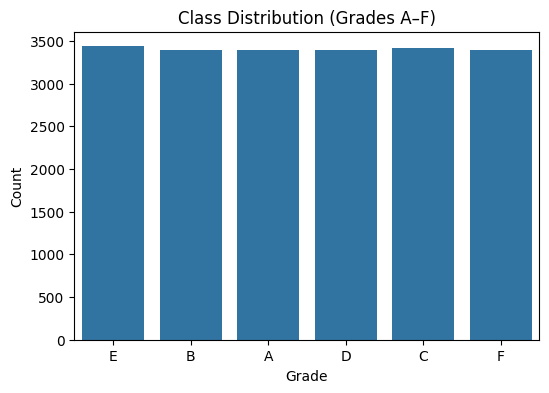

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_train)
plt.title("Class Distribution (Grades A–F)")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()


## 4.2 Random Sample Images

These images show what the handwritten letters look like after preprocessing
(reshaping, rotation correction, and normalization).  
Visual inspection helps confirm that the preprocessing steps worked correctly.


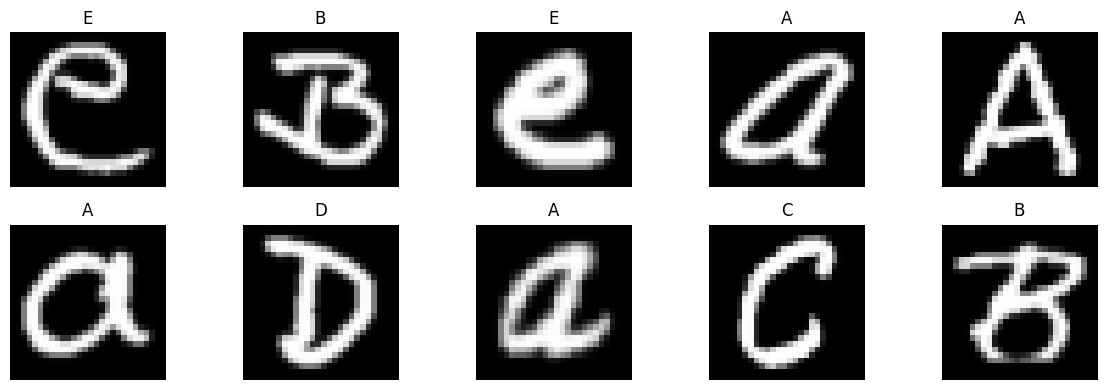

In [17]:
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.tight_layout()
plt.show()


## 4.3 Average Pixel Intensity Heatmap

This heatmap visualizes the average pixel intensity across all training images.
It reveals common stroke patterns and helps identify overall writing style trends in the dataset.


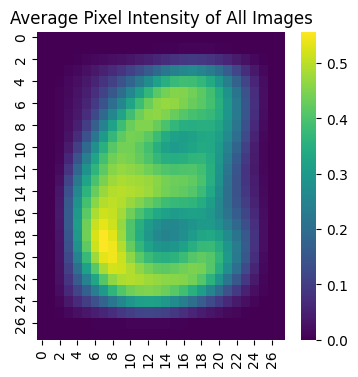

In [18]:
avg_image = np.mean(X_train.reshape(-1, 28, 28), axis=0)

plt.figure(figsize=(4,4))
sns.heatmap(avg_image, cmap="viridis")
plt.title("Average Pixel Intensity of All Images")
plt.show()


## 5. Model Training (CNN Classifier)

We use a Convolutional Neural Network (CNN) because it performs well on image data.
The model is trained to classify handwritten characters into six grade categories (A–F).

We also include:
- **EarlyStopping** to avoid overfitting  
- **ModelCheckpoint** to save the best model during training  

This ensures optimized training performance.


In [31]:
from tensorflow.keras import models, layers

model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding="same", input_shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding="same"),
    layers.Conv2D(64, (3,3), activation='relu', padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding="same"),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Dense layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(6, activation='softmax')  # A–F
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\tracy\OneDrive\Desktop\ml_pipeline_summative\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 435,558 (1.66 MB)

 Trainable params: 435,558 (1.66 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
checkpoint_path = "../models/best_model.h5"

callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True
    )
]


In [22]:
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train_encoded, test_size=0.2, random_state=SEED
)


In [23]:
history = model.fit(
    X_train_split, y_train_split,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=callbacks_list
)


Epoch 1/15
127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7164 - loss: 0.8298

128/128 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8367 - loss: 0.4868 - val_accuracy: 0.9163 - val_loss: 0.2397
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9410 - loss: 0.1840

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9496 - loss: 0.1593 - val_accuracy: 0.9560 - val_loss: 0.1301
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9632 - loss: 0.1150

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9657 - loss: 0.1088 - val_accuracy: 0.9653 - val_loss: 0.1032
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9753 - loss: 0.0867

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9748 - loss: 0.0841 - val_accuracy: 0.9692 - val_loss: 0.0907
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9807 - loss: 0.0706

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9803 - loss: 0.0686 - val_accuracy: 0.9733 - val_loss: 0.0801
Epoch 6/15
127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9826 - loss: 0.0589

128/128 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9826 - loss: 0.0582 - val_accuracy: 0.9768 - val_loss: 0.0741
Epoch 7/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9848 - loss: 0.0507 - val_accuracy: 0.9753 - val_loss: 0.0775
Epoch 8/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9866 - loss: 0.0427

128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.9862 - loss: 0.0438 - val_accuracy: 0.9773 - val_loss: 0.0707
Epoch 9/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9889 - loss: 0.0381 - val_accuracy: 0.9760 - val_loss: 0.0753
Epoch 10/15
127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9908 - loss: 0.0326

128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9916 - loss: 0.0320 - val_accuracy: 0.9785 - val_loss: 0.0707
Epoch 11/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9926 - loss: 0.0284 - val_accuracy: 0.9780 - val_loss: 0.0717
Epoch 12/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9937 - loss: 0.0243 - val_accuracy: 0.9799 - val_loss: 0.0721
Epoch 13/15
127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9960 - loss: 0.0173

128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9945 - loss: 0.0218 - val_accuracy: 0.9817 - val_loss: 0.0643
Epoch 14/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9961 - loss: 0.0161 - val_accuracy: 0.9814 - val_loss: 0.0668
Epoch 15/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9970 - loss: 0.0130 - val_accuracy: 0.9829 - val_loss: 0.0675


In [24]:
test_loss, test_acc = model.evaluate(X_test, y_test_encoded)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)


150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9777 - loss: 0.0948
Test Accuracy: 0.9777083396911621
Test Loss: 0.09476105868816376


In [25]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test_encoded, y_pred))

150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       800
           1       0.98      0.99      0.98       800
           2       0.98      0.98      0.98       800
           3       0.97      0.97      0.97       800
           4       0.97      0.97      0.97       800
           5       0.98      0.99      0.99       800

    accuracy                           0.98      4800
   macro avg       0.98      0.98      0.98      4800
weighted avg       0.98      0.98      0.98      4800



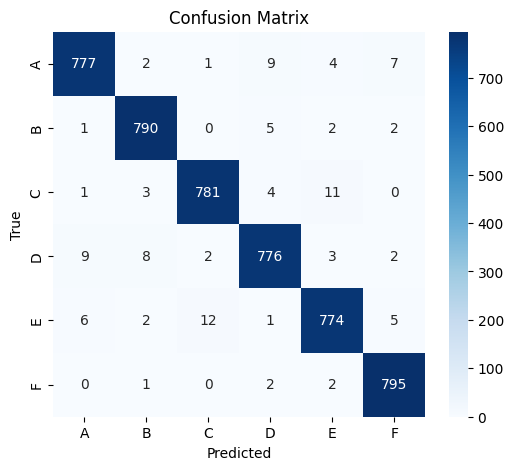

In [26]:
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [27]:
from PIL import Image


# Paths
TEST_CSV_PATH = "../data/raw/emnist-letters-test.csv"
OUTPUT_DIR = "../data/samples/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load test dataset
test_df = pd.read_csv(TEST_CSV_PATH, header=None)

# Mapping for letters A–F
label_map = {1: "A", 2: "B", 3: "C", 4: "D", 5: "E", 6: "F"}

# Filter only A–F samples
filtered = test_df[test_df[0].isin(label_map.keys())]

print("Filtered samples:", filtered.shape)

# Loop to extract one clean sample per letter
for label, letter in label_map.items():

    # Get one sample row of that letter
    row = filtered[filtered[0] == label].iloc[0, 1:].values

    # Convert to 28x28
    img = row.reshape(28, 28)

    # EMNIST fix: rotate and flip
    img = np.rot90(img, k=1)
    img = np.fliplr(img)

    # Convert to PIL image
    pil_img = Image.fromarray(img.astype(np.uint8), mode="L")

    # Save as PNG
    pil_img.save(os.path.join(OUTPUT_DIR, f"{letter}.png"))

print("Saved A–F EMNIST samples in ../data/samples/")


Filtered samples: (4800, 785)
Saved A–F EMNIST samples in ../data/samples/


## 6. Export Standardized EMNIST Test Images (A–F)

For API and Streamlit testing, we export one representative sample per class
(A–F) directly from the preprocessed EMNIST dataset. These samples are:

- exactly 28×28 grayscale
- normalized 0–1 like in training
- rotated and flipped like EMNIST preprocessing
- 100% consistent with the model’s training distribution

This ensures that the deployed model receives inputs in the same format as
training, which is important for accurate predictions.


In [30]:
from PIL import Image

SAMPLES_DIR = "../data/samples"
os.makedirs(SAMPLES_DIR, exist_ok=True)

label_to_letter = {1: "A", 2: "B", 3: "C", 4: "D", 5: "E", 6: "F"}

sample_images = {}

for numeric_label, letter in label_to_letter.items():
    # Pick first example of each class
    row = train_df_filtered[train_df_filtered[0] == numeric_label].iloc[0]
    pixels = row[pixel_cols].values.astype("uint8")

    # reshape -> preprocess exactly like training BUT WITHOUT NORMALIZING
    img = pixels.reshape(28, 28)
    img = np.rot90(img, k=1)
    img = np.fliplr(img)

    # Save raw 0–255 image EXACTLY as EMNIST provides it
    im = Image.fromarray(img, mode="L")
    save_path = os.path.join(SAMPLES_DIR, f"{letter}.png")
    im.save(save_path)

    sample_images[letter] = save_path

sample_images


{'A': '../data/samples\\A.png',
 'B': '../data/samples\\B.png',
 'C': '../data/samples\\C.png',
 'D': '../data/samples\\D.png',
 'E': '../data/samples\\E.png',
 'F': '../data/samples\\F.png'}